# More decoders

Matching decodes codes whose faults set off at most two detectors. For the rest, this
package has four decoders besides BP+OSD, each ported from its authors' code and checked
against it shot for shot (`tools/decoder_check.py`):

- **BP+LSD** (`BpLsd`; Hillmann et al., 2024): after BP, clusters grow around the detection
  events by BP's beliefs and each is solved alone. Equal to `ldpc`'s but for ties.
- **Relay-BP** (`RelayBp`; Müller et al., IBM, 2025): BP with memory, run in legs with
  random memory strengths. Identical to IBM's `relay_bp`.
- **Colour-code matching** (`ColorMatching`; Gidney and Jones, 2023): Chromobius's Möbius
  construction, which turns a colour code into a matching problem. Equal to `chromobius`
  but for ties.
- **A search decoder** (`SearchDecoder`; Beni, Higgott and Shutty, Google, 2025): Tesseract's
  A* for the most likely error. Identical to `tesseract_decoder`.

This tutorial runs them all, with BP+OSD, on a colour code and on IBM's gross code, and
plots logical error rate against time per shot.

In [1]:
import time

import numpy as np
import stabilizer_qec as sq


def compare(decoders, dets, obs):
    """Each decoder's failures and single-thread time per shot on the same shots."""
    rows = []
    for name, decoder in decoders.items():
        t0 = time.perf_counter()
        predicted = decoder.decode_batch(dets)
        seconds = (time.perf_counter() - t0) / len(dets)
        failures = int((predicted != obs).any(axis=1).sum())
        rows.append((name, failures, seconds))
        print(f"{name:16} {failures:4d} of {len(dets)} failed   {1e6 * seconds:8.1f} µs per shot")
    return rows

## A colour code

The triangular colour code at distance 5, five rounds of syndrome extraction under circuit
noise p = 0.2%. `annotate_colors=True` gives every detector Chromobius's annotation, a 4th
coordinate naming its basis and colour, which `ColorMatching` needs (the others ignore it).

In [2]:
colour = sq.CssCode.color_code(5).memory_circuit(5, 0.002, annotate_colors=True)
model = colour.detector_error_model()
dets, obs = colour.compile_detector_sampler(seed=3).sample(600, separate_observables=True)
colour_rows = compare(
    {
        "ColorMatching": sq.ColorMatching(model),
        "BP+OSD": sq.BpOsd(model, max_iter=100, osd_order=7),
        "BP+LSD": sq.BpLsd(model),
        "Relay-BP": sq.RelayBp(model),
        "SearchDecoder": sq.SearchDecoder(model),
    },
    dets,
    obs,
)

ColorMatching       7 of 600 failed        4.7 µs per shot
BP+OSD              6 of 600 failed      834.4 µs per shot
BP+LSD              7 of 600 failed      485.8 µs per shot
Relay-BP            3 of 600 failed     2192.4 µs per shot
SearchDecoder       2 of 600 failed     3638.7 µs per shot


Colour-code matching is hundreds of times faster than the rest and about as accurate as
BP+OSD; Relay-BP and the search are the most accurate. The Möbius model it matches on has
two detectors for each of the code's:

In [3]:
mobius = sq.ColorMatching(model).mobius_model
print(model.num_detectors, "detectors ->", mobius.num_detectors, "in the Möbius model,", mobius.num_errors, "edges")

90 detectors -> 180 in the Möbius model, 2388 edges


## The gross code

IBM's [[144, 12, 12]] code, six syndrome cycles at p = 0.4%. Its faults set off up to six
detectors and nothing here matches; a shot fails if any of its 12 logical qubits does.

In [4]:
gross = sq.BivariateBicycleCode("gross").memory_circuit(6, 0.004)
gmodel = gross.detector_error_model()
gdets, gobs = gross.compile_detector_sampler(seed=4).sample(150, separate_observables=True)
gross_rows = compare(
    {
        "BP+OSD": sq.BpOsd(gmodel, max_iter=100, osd_order=7),
        "BP+LSD": sq.BpLsd(gmodel, lsd_method="lsd_cs", lsd_order=10),
        "Relay-BP": sq.RelayBp(gmodel),
        "SearchDecoder": sq.SearchDecoder(gmodel, num_det_orders=4),
    },
    gdets,
    gobs,
)

BP+OSD              0 of 150 failed     2182.9 µs per shot
BP+LSD              7 of 150 failed     3199.9 µs per shot
Relay-BP            0 of 150 failed    11400.3 µs per shot
SearchDecoder       0 of 150 failed     6247.8 µs per shot


BP+LSD fails more often than BP+OSD here, and that is BP+LSD's, not the port's: `ldpc`'s own
decoders, on the same check matrix and 400 shots, fail 10 times with BP+LSD-CS of order 10
and 5 with BP+OSD-CS of order 7. LSD solves each cluster for its own lightest explanation,
where OSD weighs one solution across the whole code. It is the faster of the two on large
codes and at low noise, where clusters stay small.

## Accuracy against time

On both codes, the cost of a decoder buys accuracy only so far. The plot puts each decoder at
its time per shot and its logical error rate (with too few shots, a rate of zero is drawn at
one failure's worth, as a bound).

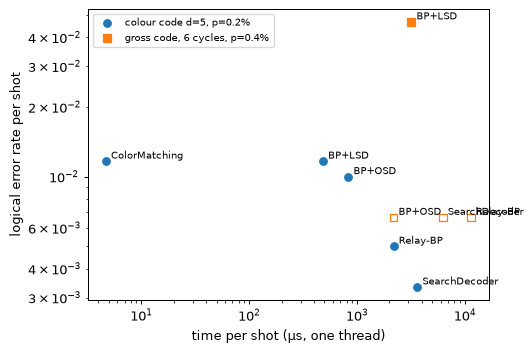

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for rows, n, marker, label in ((colour_rows, len(dets), "o", "colour code d=5"), (gross_rows, len(gdets), "s", "gross code")):
    for name, failures, seconds in rows:
        rate = max(failures, 1) / n
        ax.scatter(seconds * 1e6, rate, marker=marker, facecolors="none" if failures == 0 else None, edgecolors="C0" if marker == "o" else "C1", color="C0" if marker == "o" else "C1")
        ax.annotate(name, (seconds * 1e6, rate), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("time per shot (µs, one thread)")
ax.set_ylabel("logical error rate per shot")
ax.scatter([], [], marker="o", color="C0", label="colour code d=5, p=0.2%")
ax.scatter([], [], marker="s", color="C1", label="gross code, 6 cycles, p=0.4%")
ax.legend(fontsize=8)
fig.tight_layout()

## Exact when asked

The search's defaults are Tesseract's: a beam of 5, no revisits, 20 detector orders. With
no beam, no queue bound and revisits allowed it is exact, the most likely set of faults
(tested against brute force). On a small colour code the two find answers of the same cost:

In [6]:
small = sq.CssCode.color_code(3).memory_circuit(3, 0.006)
smodel = small.detector_error_model()
sdets, _ = small.compile_detector_sampler(seed=5).sample(300, separate_observables=True)
_, fast = sq.SearchDecoder(smodel).decode_batch(sdets, return_weights=True)
_, exact = sq.SearchDecoder(smodel, beam=None, pqlimit=None, no_revisit_dets=False, num_det_orders=1).decode_batch(sdets, return_weights=True)
print("shots where the exact search found a likelier error:", int(np.sum(exact < fast - 1e-9)), "of", len(sdets))

shots where the exact search found a likelier error: 0 of 300


## How these are checked

`python tools/decoder_check.py` runs each decoder against its authors' package on the same
check matrices and shots: BP+LSD's corrections equal `ldpc`'s (and its clusters list their
faults in `ldpc`'s order); Relay-BP's corrections, convergence and iteration counts equal
IBM's; colour-code matching's Möbius matching weighs the same as Chromobius's on every shot,
its predictions differing only between equally light matchings; and the search finds
Tesseract's faults, fault for fault.